# Endox IA Reduced

Modelo reducido

Versión: 2.0

## 1. Accesos a Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import os
from PIL import Image

base_path = '/content/drive/MyDrive/Proyectos/limas-endodonticas/dataset'
flat_dataset = '/content/drive/MyDrive/Proyectos/limas-endodonticas/dataset_flat_reduced'

## 2. Aplanar el dataset

In [ ]:
# Sistemas incluidos en este modelo reducido
SISTEMAS = {
  '3d-files',
  'blue-shaper',
  'apical-shaper',
  'mg3-blue',
  'rising',
  'micromega-one-curve-mini',
  'slim-shaper',
  'micromega-remover'
}

valid_ext = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

os.makedirs(flat_dataset, exist_ok=True)

total_images = 0
total_classes = 0
class_distribution = {}

for sistema in os.listdir(base_path):
  if sistema not in SISTEMAS:
    continue

  sistema_path = os.path.join(base_path, sistema)
  if not os.path.isdir(sistema_path):
    continue

  for lima in os.listdir(sistema_path):
    lima_path = os.path.join(sistema_path, lima)
    if not os.path.isdir(lima_path):
      continue

    class_name = f"{sistema}_{lima}"
    dest_path = os.path.join(flat_dataset, class_name)
    os.makedirs(dest_path, exist_ok=True)

    for filename in os.listdir(lima_path):
      if not filename.lower().endswith(valid_ext):
        continue

      src = os.path.join(lima_path, filename)
      dst = os.path.join(dest_path, filename)

      if os.path.exists(dst):
        continue

      img = Image.open(src)
      w, h = img.size
      target_ratio = 3 / 4

      if (w / h) > target_ratio:
        new_w = int(h * target_ratio)
        left = (w - new_w) // 2
        img = img.crop((left, 0, left + new_w, h))
      else:
        new_h = int(w / target_ratio)
        top = (h - new_h) // 2
        img = img.crop((0, top, w, top + new_h))

      img.save(dst)

    num_images = len([f for f in os.listdir(dest_path) if f.lower().endswith(valid_ext)])
    class_distribution[class_name] = num_images
    total_images += num_images
    total_classes += 1

print(f"Dataset preparado:")
print(f"   - Sistemas incluidos: {len(SISTEMAS)}")
print(f"   - Total de clases (limas): {total_classes}")
print(f"   - Total de imágenes: {total_images}")
print(f"   - Promedio imágenes/clase: {total_images/total_classes:.1f}")
print(f"\nDistribución por clase:")
for class_name, count in sorted(class_distribution.items()):
  print(f"   {class_name}: {count} imágenes")

Dataset preparado:
   - Sistemas incluidos: 8
   - Total de clases (limas): 29
   - Total de imágenes: 5364
   - Promedio imágenes/clase: 185.0

Distribución por clase:
   3d-files_1-f25: 176 imágenes
   3d-files_2-f30: 173 imágenes
   3d-files_3-s30: 178 imágenes
   apical-shaper_1-z30: 176 imágenes
   apical-shaper_2-z35: 175 imágenes
   apical-shaper_3-z40: 199 imágenes
   apical-shaper_4-z50: 163 imágenes
   blue-shaper_1-z1: 187 imágenes
   blue-shaper_2-z2: 186 imágenes
   blue-shaper_3-z3: 193 imágenes
   blue-shaper_4-z4: 190 imágenes
   mg3-blue_1-sv: 207 imágenes
   mg3-blue_2-px: 204 imágenes
   mg3-blue_3-g1: 198 imágenes
   mg3-blue_4-g2x: 208 imágenes
   mg3-blue_5-g2: 215 imágenes
   micromega-one-curve-mini_1-n45-0.4: 158 imágenes
   micromega-one-curve-mini_2-n35-0.4: 139 imágenes
   micromega-one-curve-mini_3-n25-0.6: 160 imágenes
   micromega-one-curve-mini_4-n25-0.4: 141 imágenes
   micromega-remover_1-n30: 174 imágenes
   rising_1-17: 204 imágenes
   rising_2-13: 2

### Datasets para entrenamiento y validación

Se divide el dataset original en un conjunto de entrenamiento y otro para la validación con una distribución del 80% y 20%, respectivamente.

In [3]:
import tensorflow as tf
import numpy as np

In [4]:
IMG_SIZE = (448, 448)
BATCH_SIZE = 16
DATA_DIR = flat_dataset

train_dataset = tf.keras.utils.image_dataset_from_directory(
  DATA_DIR,
  validation_split=0.2,
  subset="training",
  seed=42,
  image_size=IMG_SIZE,
  batch_size=BATCH_SIZE,
  color_mode='rgb'
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
  DATA_DIR,
  validation_split=0.2,
  subset="validation",
  seed=42,
  image_size=IMG_SIZE,
  batch_size=BATCH_SIZE,
  color_mode='rgb'
)

class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)

print(f"Dataset cargado:")
print(f"   - Clases: {NUM_CLASSES}")
print(f"   - Tamaño imagen: {IMG_SIZE}")
print(f"   - Batch size: {BATCH_SIZE}")
print(f"\nClases:")
for i, name in enumerate(class_names):
  print(f"   {i}: {name}")

Found 5364 files belonging to 29 classes.
Using 4292 files for training.
Found 5364 files belonging to 29 classes.
Using 1072 files for validation.
Dataset cargado:
   - Clases: 29
   - Tamaño imagen: (448, 448)
   - Batch size: 16

Clases:
   0: 3d-files_1-f25
   1: 3d-files_2-f30
   2: 3d-files_3-s30
   3: apical-shaper_1-z30
   4: apical-shaper_2-z35
   5: apical-shaper_3-z40
   6: apical-shaper_4-z50
   7: blue-shaper_1-z1
   8: blue-shaper_2-z2
   9: blue-shaper_3-z3
   10: blue-shaper_4-z4
   11: mg3-blue_1-sv
   12: mg3-blue_2-px
   13: mg3-blue_3-g1
   14: mg3-blue_4-g2x
   15: mg3-blue_5-g2
   16: micromega-one-curve-mini_1-n45-0.4
   17: micromega-one-curve-mini_2-n35-0.4
   18: micromega-one-curve-mini_3-n25-0.6
   19: micromega-one-curve-mini_4-n25-0.4
   20: micromega-remover_1-n30
   21: rising_1-17
   22: rising_2-13
   23: rising_3-25
   24: rising_4-30
   25: rising_5-28
   26: slim-shaper_1-zs1
   27: slim-shaper_2-zs2
   28: slim-shaper_3-zs3


## 3. Data augmentation

In [5]:
# Función para transformaciones
class RandomRotate90(tf.keras.layers.Layer):
  def call(self, images, training=None):
    if training:
      k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
      return tf.image.rot90(images, k=k)
    return images

In [6]:
# Augmentation
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomFlip('vertical'),
  RandomRotate90(),
  tf.keras.layers.RandomZoom(0.3),
  tf.keras.layers.RandomBrightness(0.3),
  tf.keras.layers.RandomContrast(0.3),
])

AUTOTUNE = tf.data.AUTOTUNE
train_dataset_augmented = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)

print("Augmentation definido:")
print("   - RandomFlip horizontal y vertical")
print("   - RandomRotate90 (0°, 90°, 180°, 270°)")
print("   - RandomZoom: ±30%")
print("   - RandomBrightness: ±30%")
print("   - RandomContrast: ±30%")

Augmentation definido:
   - RandomFlip horizontal y vertical
   - RandomRotate90 (0°, 90°, 180°, 270°)
   - RandomZoom: ±30%
   - RandomBrightness: ±30%
   - RandomContrast: ±30%


## 4. Construcción del modelo

In [7]:
# Construcción del modelo
base_model = tf.keras.applications.EfficientNetB2(
  input_shape=IMG_SIZE + (3,),
  include_top=False,
  weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(512, activation='relu')(x)
x = tf.keras.layers.Dropout(0.4)(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
  loss=tf.keras.losses.SparseCategoricalCrossentropy(),
  metrics=[
    'accuracy',
    tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top_3_accuracy'),
    tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top_5_accuracy')
  ]
)

print(f"Modelo construido")
print(f"   - Base: EfficientNetB2")
print(f"   - Parámetros totales: {model.count_params():,}")
print(f"   - Clases: {NUM_CLASSES}")

31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Modelo construido
   - Base: EfficientNetB2
   - Parámetros totales: 8,635,414
   - Clases: 29


## 5. Entrenamiento del modelo

### Fase 1: entrenamiento con el modelo base

In [8]:
# Entrenamiento Fase 1
callbacks_phase1 = [
  tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
  ),
  tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
  )
]

NUM_EPOCHS = 25

print("Fase 1: Entrenamiento (modelo base congelado)")
print("   - Learning rate: 1e-4")
print(f"   - Epochs: {NUM_EPOCHS} (con early stopping)")
print()

history_phase1 = model.fit(
  train_dataset_augmented,
  validation_data=validation_dataset,
  epochs=NUM_EPOCHS,
  callbacks=callbacks_phase1,
  verbose=1
)

Fase 1: Entrenamiento (modelo base congelado)
   - Learning rate: 1e-4
   - Epochs: 25 (con early stopping)

Epoch 1/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 1122s 4s/step - accuracy: 0.1274 - loss: 3.5438 - top_3_accuracy: 0.2761 - top_5_accuracy: 0.3966 - val_accuracy: 0.2715 - val_loss: 2.5627 - val_top_3_accuracy: 0.5205 - val_top_5_accuracy: 0.6502 - learning_rate: 1.0000e-04
Epoch 2/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 175s 651ms/step - accuracy: 0.3017 - loss: 2.4093 - top_3_accuracy: 0.5643 - top_5_accuracy: 0.6866 - val_accuracy: 0.6465 - val_loss: 1.3050 - val_top_3_accuracy: 0.8890 - val_top_5_accuracy: 0.9440 - learning_rate: 1.0000e-04
Epoch 3/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 171s 636ms/step - accuracy: 0.4438 - loss: 1.8471 - top_3_accuracy: 0.7055 - top_5_accuracy: 0.8129 - val_accuracy: 0.7463 - val_loss: 0.8733 - val_top_3_accuracy: 0.9580 - val_top_5_accuracy: 0.9804 - learning_rate: 1.0000e-04
Epoch 4/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 175s 652ms/step - accuracy: 0.5133 - loss: 1.5546

### Fase 2: ajuste fino

In [ ]:
# Fase 2: Fine-tuning
base_model.trainable = True

for layer in base_model.layers[:-40]:
  layer.trainable = False

model.compile(
  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
  loss=tf.keras.losses.SparseCategoricalCrossentropy(),
  metrics=[
    'accuracy',
    tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top_3_accuracy'),
    tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top_5_accuracy')
  ]
)

callbacks_phase2 = [
  tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True,
    verbose=1
  ),
  tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-8,
    verbose=1
  )
]

NUM_EPOCHS = 20

print("Fase 2: Fine-tuning")
print("   - Capas descongeladas: últimas 40 de EfficientNetB2")
print("   - Learning rate: 1e-5")
print(f"   - Epochs: {NUM_EPOCHS} (con early stopping)")
print()

history_phase2 = model.fit(
  train_dataset_augmented,
  validation_data=validation_dataset,
  epochs=NUM_EPOCHS,
  callbacks=callbacks_phase2,
  verbose=1
)

Fase 2: Fine-tuning
   - Capas descongeladas: últimas 30 de EfficientNetB2
   - Learning rate: 1e-5
   - Epochs: 20 (con early stopping)

Epoch 1/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 206s 691ms/step - accuracy: 0.6456 - loss: 1.1013 - top_3_accuracy: 0.8828 - top_5_accuracy: 0.9434 - val_accuracy: 0.9104 - val_loss: 0.2585 - val_top_3_accuracy: 0.9935 - val_top_5_accuracy: 0.9972 - learning_rate: 1.0000e-05
Epoch 2/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 171s 634ms/step - accuracy: 0.7181 - loss: 0.8454 - top_3_accuracy: 0.9278 - top_5_accuracy: 0.9664 - val_accuracy: 0.9198 - val_loss: 0.2359 - val_top_3_accuracy: 0.9944 - val_top_5_accuracy: 0.9981 - learning_rate: 1.0000e-05
Epoch 3/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 169s 628ms/step - accuracy: 0.7423 - loss: 0.7469 - top_3_accuracy: 0.9473 - top_5_accuracy: 0.9767 - val_accuracy: 0.9282 - val_loss: 0.2053 - val_top_3_accuracy: 0.9963 - val_top_5_accuracy: 1.0000 - learning_rate: 1.0000e-05
Epoch 4/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 203s 634ms/step - 

## 6. Evaluación del modelo

In [10]:
# Evaluación final
print("Evaluación final del modelo")
print("=" * 50)

val_results = model.evaluate(validation_dataset, verbose=0)

print(f"\nMétricas de validación:")
print(f"   - Loss:           {val_results[0]:.4f}")
print(f"   - Accuracy:       {val_results[1]:.2%}")
print(f"   - Top-3 Accuracy: {val_results[2]:.2%}")
print(f"   - Top-5 Accuracy: {val_results[3]:.2%}")

print(f"\nInterpretación:")
if val_results[1] >= 0.95:
  print(f"   ✓ Rendimiento excelente (>95%)")
elif val_results[1] >= 0.85:
  print(f"   ✓ Rendimiento muy bueno (85-95%)")
elif val_results[1] >= 0.75:
  print(f"   ✓ Rendimiento aceptable (75-85%)")
else:
  print(f"   ✗ Rendimiento bajo (<75%) - revisar datos o modelo")

Evaluación final del modelo

Métricas de validación:
   - Loss:           0.0906
   - Accuracy:       97.20%
   - Top-3 Accuracy: 100.00%
   - Top-5 Accuracy: 100.00%

Interpretación:
   ✓ Rendimiento excelente (>95%)


In [11]:
for images, labels in validation_dataset.take(1):
  sample_image = images[0]
  sample_label = labels[0].numpy()

# Predecir
img_array = tf.expand_dims(sample_image, 0)
predictions = model.predict(img_array, verbose=0)[0]

top_k = 5
top_k_indices = np.argsort(predictions)[-top_k:][::-1]

print(f"Clase real: {class_names[sample_label]}")
print(f"\nTop {top_k} predicciones:")
for i, idx in enumerate(top_k_indices):
  print(f"   {i+1}. {class_names[idx]}: {predictions[idx]*100:.2f}%")

Clase real: micromega-one-curve-mini_2-n35-0.4

Top 5 predicciones:
   1. micromega-one-curve-mini_2-n35-0.4: 91.63%
   2. micromega-one-curve-mini_3-n25-0.6: 6.45%
   3. slim-shaper_2-zs2: 0.48%
   4. micromega-one-curve-mini_1-n45-0.4: 0.37%
   5. micromega-one-curve-mini_4-n25-0.4: 0.32%


### Precisión individual por clase

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

In [13]:
# Obtener predicciones y etiquetas reales
y_true = []
y_pred = []

for images, labels in validation_dataset:
  predictions = model.predict(images, verbose=0)
  y_pred.extend(np.argmax(predictions, axis=1))
  y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Precisión por clase
report = classification_report(
  y_true,
  y_pred,
  target_names=class_names,
  output_dict=True
)

# Ordenar clases por precisión descendente
class_precisions = {
  name: report[name]['precision']
  for name in class_names
}
class_precisions_sorted = sorted(
  class_precisions.items(),
  key=lambda x: x[1],
  reverse=True
)

print("Precisión por clase (ordenada):")
print(f"{'Clase':<40} {'Precisión':>10}")
print("-" * 52)
for class_name, precision in class_precisions_sorted:
  bar = "█" * int(precision * 20)
  print(f"{class_name:<40} {precision*100:>8.2f}%  {bar}")

print(f"\nMedia:  {report['macro avg']['precision']*100:.2f}%")
print(f"Accuracy total: {report['accuracy']*100:.2f}%")

Precisión por clase (ordenada):
Clase                                     Precisión
----------------------------------------------------
3d-files_1-f25                             100.00%  ████████████████████
3d-files_2-f30                             100.00%  ████████████████████
3d-files_3-s30                             100.00%  ████████████████████
apical-shaper_2-z35                        100.00%  ████████████████████
apical-shaper_3-z40                        100.00%  ████████████████████
apical-shaper_4-z50                        100.00%  ████████████████████
blue-shaper_1-z1                           100.00%  ████████████████████
blue-shaper_2-z2                           100.00%  ████████████████████
blue-shaper_3-z3                           100.00%  ████████████████████
blue-shaper_4-z4                           100.00%  ████████████████████
mg3-blue_3-g1                              100.00%  ████████████████████
micromega-one-curve-mini_2-n35-0.4         100.00%  ████████

## 7. Visualización

### Gráfico del historial del entrenamiento

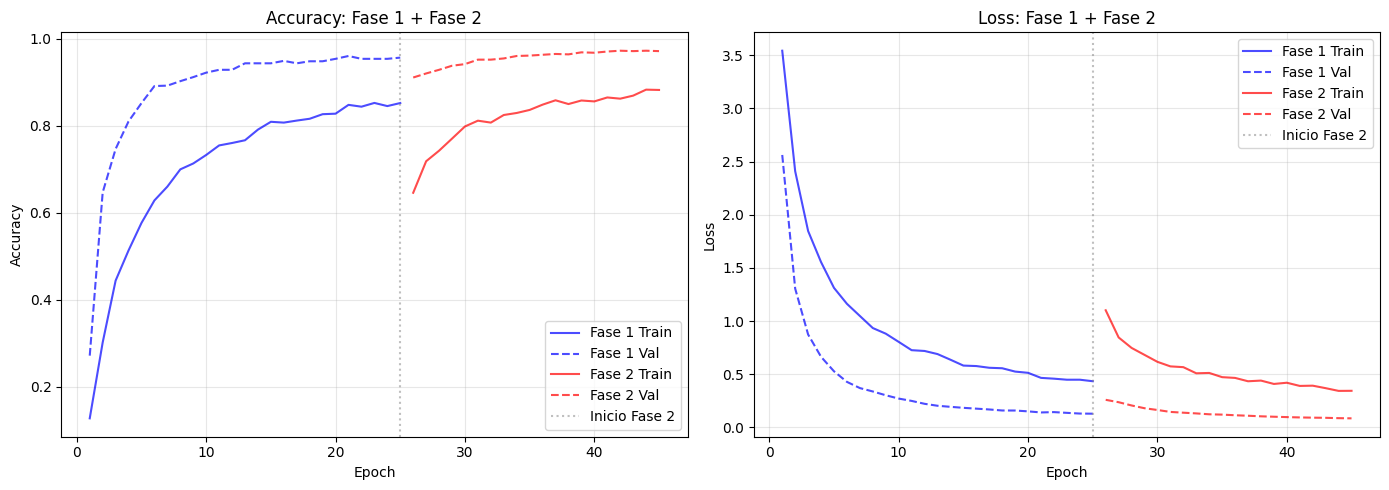

In [14]:
def plot_history(history1, history2, metric, title):
  epochs1 = range(1, len(history1.history[metric]) + 1)
  epochs2 = range(
    len(epochs1) + 1,
    len(epochs1) + len(history2.history[metric]) + 1
  )

  plt.plot(epochs1, history1.history[metric], 'b-', label='Fase 1 Train', alpha=0.7)
  plt.plot(epochs1, history1.history[f'val_{metric}'], 'b--', label='Fase 1 Val', alpha=0.7)
  plt.plot(epochs2, history2.history[metric], 'r-', label='Fase 2 Train', alpha=0.7)
  plt.plot(epochs2, history2.history[f'val_{metric}'], 'r--', label='Fase 2 Val', alpha=0.7)
  plt.axvline(x=len(epochs1), color='gray', linestyle=':', alpha=0.5, label='Inicio Fase 2')
  plt.xlabel('Epoch')
  plt.ylabel(metric.capitalize())
  plt.title(title)
  plt.legend(loc='best')
  plt.grid(alpha=0.3)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plot_history(history_phase1, history_phase2, 'accuracy', 'Accuracy: Fase 1 + Fase 2')

plt.subplot(1, 2, 2)
plot_history(history_phase1, history_phase2, 'loss', 'Loss: Fase 1 + Fase 2')

plt.tight_layout()
plt.show()

### Matriz de confusión

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

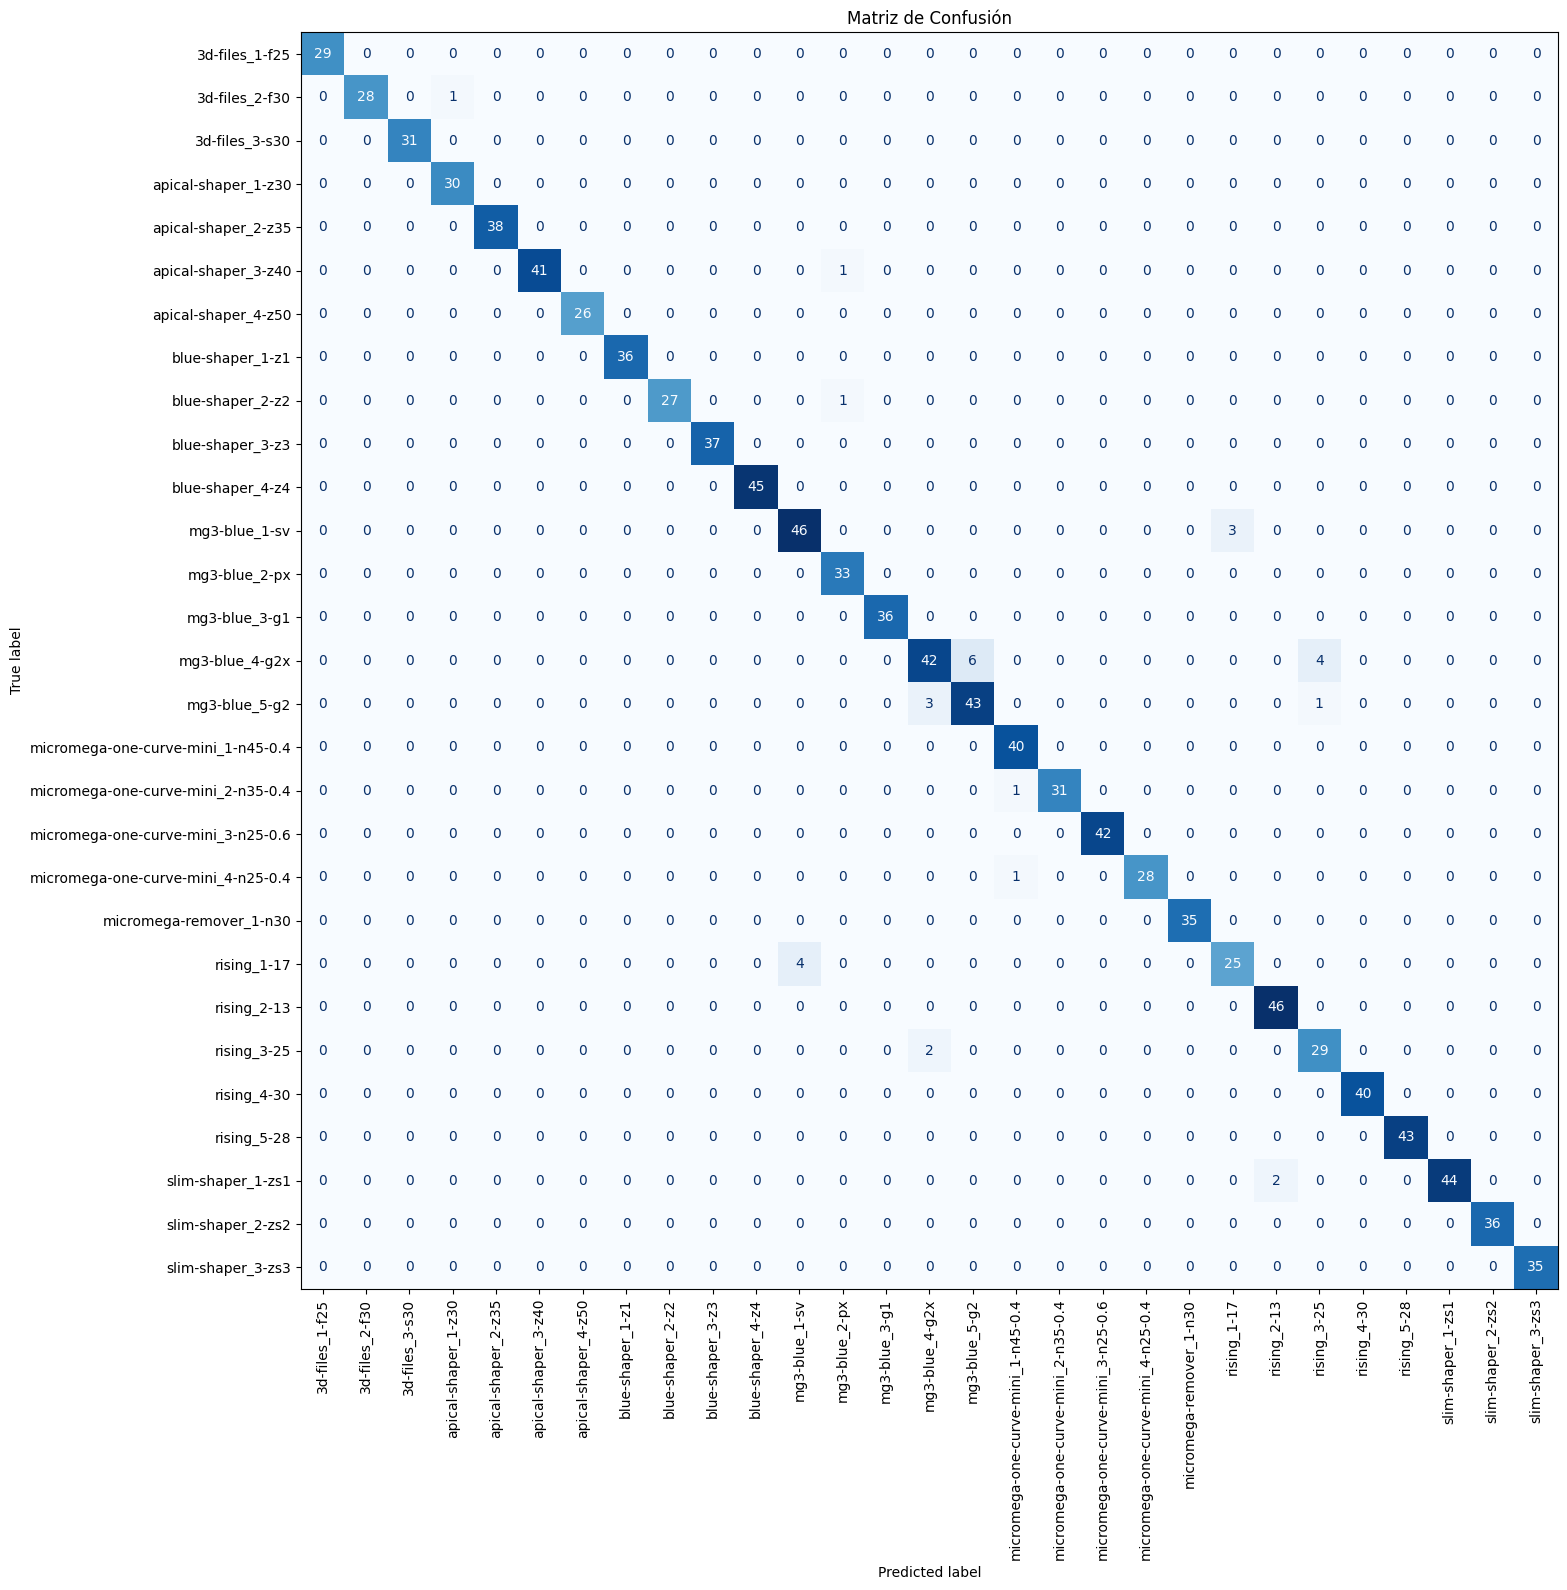

In [16]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 16))
disp = ConfusionMatrixDisplay(
  confusion_matrix=cm,
  display_labels=class_names
)
disp.plot(
  cmap=plt.cm.Blues,
  xticks_rotation='vertical',
  ax=plt.gca(),
  colorbar=False
)
plt.title('Matriz de Confusión')
plt.tight_layout()
plt.show()

## 8. Exportar el modelo

### Reconstrucción del modelo de inferencia

In [17]:
# Reconstruir modelo de inferencia sin augmentation
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(512, activation='relu')(x)
x = tf.keras.layers.Dropout(0.4)(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)

inference_model = tf.keras.Model(inputs, outputs)

# Transferir pesos
for inf_layer, train_layer in zip(inference_model.layers[1:], model.layers[2:]):
  inf_layer.set_weights(train_layer.get_weights())

# Verificar accuracy
inference_model.compile(
  optimizer='adam',
  loss=tf.keras.losses.SparseCategoricalCrossentropy(),
  metrics=['accuracy']
)
results = inference_model.evaluate(validation_dataset, verbose=0)
print(f"Accuracy inference_model: {results[1]:.2%}")

Accuracy inference_model: 97.20%


### Exportar

In [19]:
!pip install tensorflowjs -q

In [20]:
import os
import shutil

model_output_path = '/content/drive/MyDrive/Proyectos/limas-endodonticas/modelo/outputs/endox-ia-reduced-v2'
os.makedirs(model_output_path, exist_ok=True)

saved_model_local = '/content/saved_model'
tfjs_local = '/content/tfjs'

for path in [saved_model_local, tfjs_local]:
  if os.path.exists(path):
    shutil.rmtree(path)

# Keras en Drive
keras_path = os.path.join(model_output_path, 'endox-ia-reduced.keras')
inference_model.save(keras_path)
print(f"✓ Keras guardado: {keras_path}")

# SavedModel en disco local
tf.saved_model.save(inference_model, saved_model_local)
print(f"✓ SavedModel local: {os.listdir(saved_model_local)}")

# Convertir a tfjs en disco local
os.environ['SAVED_MODEL_LOCAL'] = saved_model_local
os.environ['TFJS_LOCAL'] = tfjs_local
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    --output_format=tfjs_graph_model \
    $SAVED_MODEL_LOCAL \
    $TFJS_LOCAL
print(f"✓ tfjs local: {os.listdir(tfjs_local)}")

# Copiar a Drive
saved_model_drive = os.path.join(model_output_path, 'saved_model')
tfjs_drive = os.path.join(model_output_path, 'tfjs')
shutil.copytree(saved_model_local, saved_model_drive, dirs_exist_ok=True)
shutil.copytree(tfjs_local, tfjs_drive, dirs_exist_ok=True)

print(f"✓ SavedModel en Drive: {os.listdir(saved_model_drive)}")
print(f"✓ tfjs en Drive: {os.listdir(tfjs_drive)}")

✓ Keras guardado: /content/drive/MyDrive/Proyectos/limas-endodonticas/modelo/outputs/endox-ia-reduced-v2/endox-ia-reduced.keras
✓ SavedModel local: ['saved_model.pb', 'fingerprint.pb', 'variables', 'assets']
2026-08-07 03:20:08.341002: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786072808.364269   49144 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786072808.372253   49144 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1786072808.393824   49144 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786072808.393879   49144 computation_plac